In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Configurações para visualização
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("="*60)
print("PIPELINE DE PREDIÇÃO DE FALHAS EM MÁQUINAS")
print("="*60)

# Carregamento dos dados
df = pd.read_csv('/content/manutencao_preditiva (2).csv')

PIPELINE DE PREDIÇÃO DE FALHAS EM MÁQUINAS



1. ANÁLISE EXPLORATÓRIA
----------------------------------------
Shape do dataset: (10000, 10)

Colunas: ['UDI', 'ID Produto', 'Tipo', 'Temperatura Ar [K]', 'Temperatura Processo [K]', 'Velocidade Rotacao [rpm]', 'Torque [Nm]', 'Desgaste Ferramenta [min]', 'Alvo', 'Tipo da Falha']

Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   UDI                        10000 non-null  int64  
 1   ID Produto                 10000 non-null  object 
 2   Tipo                       10000 non-null  object 
 3   Temperatura Ar [K]         10000 non-null  float64
 4   Temperatura Processo [K]   10000 non-null  float64
 5   Velocidade Rotacao [rpm]   10000 non-null  int64  
 6   Torque [Nm]                10000 non-null  float64
 7   Desgaste Ferramenta [min]  10000 non-null  int64  
 8   Alvo                   

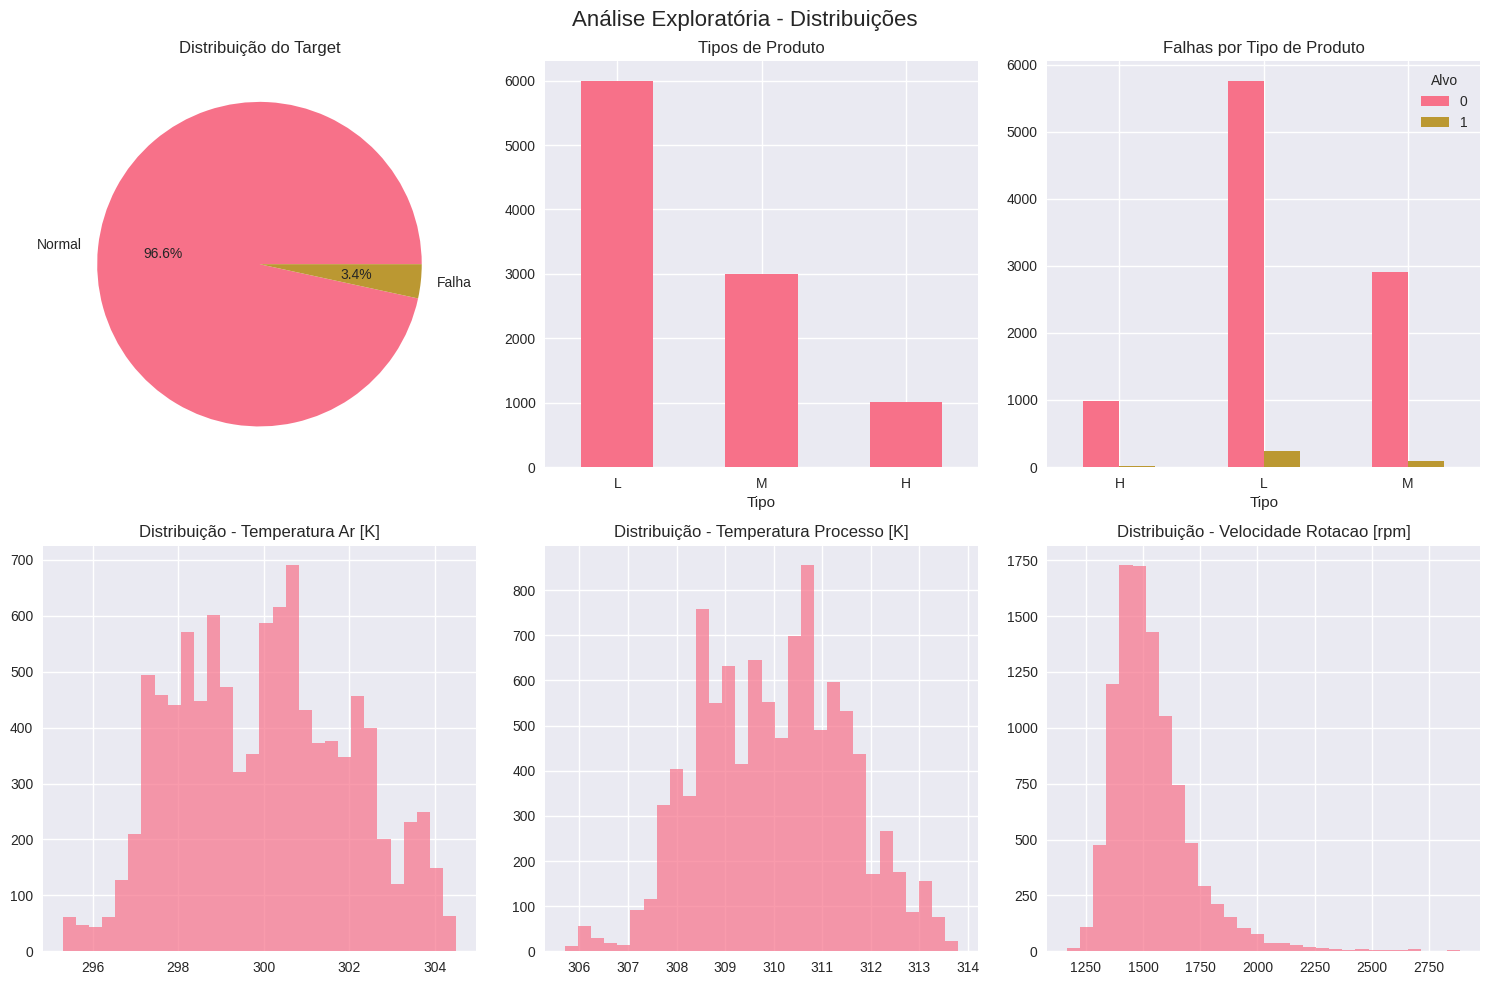

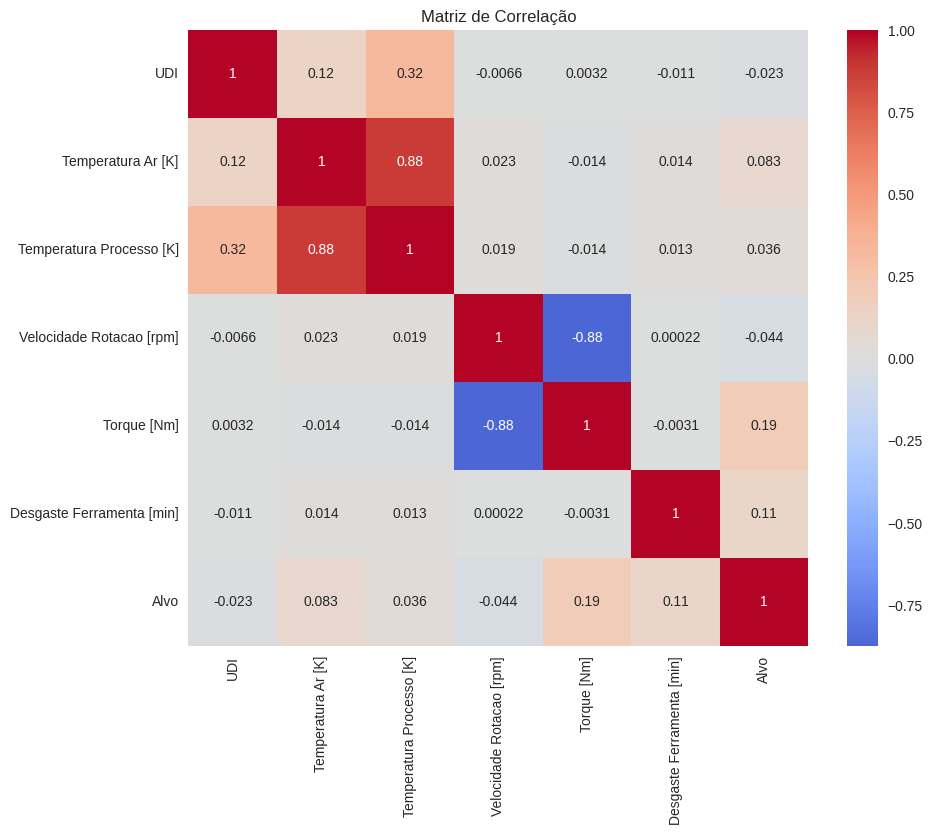

In [ ]:
print("\n1. ANÁLISE EXPLORATÓRIA")
print("-"*40)


print(f"Shape do dataset: {df.shape}")
print(f"\nColunas: {list(df.columns)}")

# Informações básicas
print("\nInformações gerais:")
print(df.info())

print("\nEstatísticas descritivas:")
print(df.describe())

# Análise da variável target
print(f"\nDistribuição da variável target (Alvo):")
print(df['Alvo'].value_counts())
print(f"Percentual de falhas: {df['Alvo'].mean()*100:.2f}%")

print(f"\nTipos de falhas:")
print(df['Tipo da Falha'].value_counts())

print(f"\nTipos de produtos:")
print(df['Tipo'].value_counts())

# Visualizações
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Análise Exploratória - Distribuições', fontsize=16)

# Distribuição da variável target
axes[0,0].pie(df['Alvo'].value_counts(), labels=['Normal', 'Falha'], autopct='%1.1f%%')
axes[0,0].set_title('Distribuição do Target')

# Distribuição dos tipos de produto
df['Tipo'].value_counts().plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Tipos de Produto')
axes[0,1].tick_params(axis='x', rotation=0)

# Distribuição de falhas por tipo de produto
pd.crosstab(df['Tipo'], df['Alvo']).plot(kind='bar', ax=axes[0,2])
axes[0,2].set_title('Falhas por Tipo de Produto')
axes[0,2].tick_params(axis='x', rotation=0)

# Histogramas das variáveis numéricas principais
numeric_cols = ['Temperatura Ar [K]', 'Temperatura Processo [K]', 'Velocidade Rotacao [rpm]']
for i, col in enumerate(numeric_cols):
    axes[1,i].hist(df[col], bins=30, alpha=0.7)
    axes[1,i].set_title(f'Distribuição - {col}')

plt.tight_layout()
plt.show()

# Matriz de correlação
plt.figure(figsize=(10, 8))
numeric_columns = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlação')
plt.show()

In [ ]:
# ================================================================
# ETAPA 2: REMOÇÃO DE RUÍDOS, INCONSISTÊNCIAS E DADOS FALTANTES
# ================================================================
print("\n2. REMOÇÃO DE RUÍDOS E INCONSISTÊNCIAS")
print("-"*40)

print("Verificando dados faltantes:")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

if missing_data.sum() == 0:
    print("✓ Nenhum dado faltante encontrado!")

# Verificação de duplicatas
duplicates = df.duplicated().sum()
print(f"\nDuplicatas encontradas: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"✓ {duplicates} duplicatas removidas!")

# Detecção e remoção de outliers usando IQR
def remove_outliers_iqr(dataframe, columns):
    df_clean = dataframe.copy()
    outliers_info = {}

    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers_mask = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
        outliers_count = outliers_mask.sum()
        outliers_info[col] = outliers_count

        df_clean = df_clean[~outliers_mask]

    return df_clean, outliers_info

# Aplicar remoção de outliers nas variáveis numéricas principais
numeric_features = ['Temperatura Ar [K]', 'Temperatura Processo [K]',
                   'Velocidade Rotacao [rpm]', 'Torque [Nm]', 'Desgaste Ferramenta [min]']

df_clean, outliers_info = remove_outliers_iqr(df, numeric_features)

print(f"\nOutliers removidos por coluna:")
for col, count in outliers_info.items():
    print(f"  {col}: {count} outliers")

print(f"\nShape após limpeza: {df_clean.shape}")
print(f"Registros removidos: {df.shape[0] - df_clean.shape[0]}")

# ================================================================
# APLICAÇÃO DO MÉTODO mRMR (minimum Redundancy Maximum Relevance)
# ================================================================
print(f"\nAplicando método mRMR para análise de relevância:")

# Preparação dos dados para mRMR
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import pearsonr

def mrmr_score(X, y, selected_features, candidate_feature):
    """
    Calcula o score mRMR para uma feature candidata
    mRMR = Relevância - Redundância
    """
    # Relevância: Informação Mútua com o target
    relevance = mutual_info_classif(X[[candidate_feature]], y)[0]

    # Redundância: Correlação média com features já selecionadas
    if len(selected_features) == 0:
        redundancy = 0
    else:
        correlations = []
        for selected_feat in selected_features:
            corr, _ = pearsonr(X[candidate_feature], X[selected_feat])
            correlations.append(abs(corr))
        redundancy = np.mean(correlations)

    return relevance - redundancy

# Preparar dados numéricos para mRMR
df_numeric = df_clean.select_dtypes(include=[np.number])
features_for_mrmr = [col for col in df_numeric.columns if col not in ['UDI', 'Alvo']]
X_mrmr = df_numeric[features_for_mrmr]
y_mrmr = df_numeric['Alvo']

# Aplicar mRMR para selecionar top 5 features
selected_features_mrmr = []
remaining_features = features_for_mrmr.copy()
mrmr_scores = {}

print("Seleção de features por mRMR:")
for i in range(min(5, len(features_for_mrmr))):
    best_score = -np.inf
    best_feature = None

    for feature in remaining_features:
        score = mrmr_score(X_mrmr, y_mrmr, selected_features_mrmr, feature)
        if score > best_score:
            best_score = score
            best_feature = feature

    selected_features_mrmr.append(best_feature)
    remaining_features.remove(best_feature)
    mrmr_scores[best_feature] = best_score
    print(f"  {i+1}. {best_feature} (mRMR score: {best_score:.4f})")

print(f"\n✓ Top 5 features por mRMR: {selected_features_mrmr}")


2. REMOÇÃO DE RUÍDOS E INCONSISTÊNCIAS
----------------------------------------
Verificando dados faltantes:
Series([], dtype: int64)
✓ Nenhum dado faltante encontrado!

Duplicatas encontradas: 0

Outliers removidos por coluna:
  Temperatura Ar [K]: 0 outliers
  Temperatura Processo [K]: 0 outliers
  Velocidade Rotacao [rpm]: 418 outliers
  Torque [Nm]: 47 outliers
  Desgaste Ferramenta [min]: 0 outliers

Shape após limpeza: (9535, 10)
Registros removidos: 465

Aplicando método mRMR para análise de relevância:
Seleção de features por mRMR:
  1. Torque [Nm] (mRMR score: 0.0254)
  2. Desgaste Ferramenta [min] (mRMR score: 0.0086)
  3. Temperatura Ar [K] (mRMR score: -0.0030)
  4. Velocidade Rotacao [rpm] (mRMR score: -0.2840)
  5. Temperatura Processo [K] (mRMR score: -0.2255)

✓ Top 5 features por mRMR: ['Torque [Nm]', 'Desgaste Ferramenta [min]', 'Temperatura Ar [K]', 'Velocidade Rotacao [rpm]', 'Temperatura Processo [K]']


In [ ]:
# ================================================================
# ETAPA 3: CODIFICAÇÃO DE VARIÁVEIS CATEGÓRICAS
# ================================================================
print("\n3. CODIFICAÇÃO DE VARIÁVEIS CATEGÓRICAS")
print("-"*40)

df_encoded = df_clean.copy()

# Identificar variáveis categóricas
categorical_columns = df_encoded.select_dtypes(include=['object']).columns
print(f"Variáveis categóricas encontradas: {list(categorical_columns)}")

# Label Encoding para variáveis categóricas
label_encoders = {}

for col in categorical_columns:
    if col != 'Tipo da Falha':  # Não codificar a variável de tipo de falha pois não será usada como feature
        le = LabelEncoder()
        df_encoded[col + '_encoded'] = le.fit_transform(df_encoded[col])
        label_encoders[col] = le
        print(f"✓ {col} codificada -> {col}_encoded")

# Remover colunas categóricas originais (exceto ID que pode ser útil para referência)
columns_to_remove = [col for col in categorical_columns if col not in ['ID Produto', 'Tipo da Falha']]
df_encoded = df_encoded.drop(columns=columns_to_remove)

print(f"\nColunas após codificação: {list(df_encoded.columns)}")


3. CODIFICAÇÃO DE VARIÁVEIS CATEGÓRICAS
----------------------------------------
Variáveis categóricas encontradas: ['ID Produto', 'Tipo', 'Tipo da Falha']
✓ ID Produto codificada -> ID Produto_encoded
✓ Tipo codificada -> Tipo_encoded

Colunas após codificação: ['UDI', 'ID Produto', 'Temperatura Ar [K]', 'Temperatura Processo [K]', 'Velocidade Rotacao [rpm]', 'Torque [Nm]', 'Desgaste Ferramenta [min]', 'Alvo', 'Tipo da Falha', 'ID Produto_encoded', 'Tipo_encoded']


In [ ]:
# ================================================================
# ETAPA 4: BALANCEAMENTO DE CLASSES
# ================================================================
print("\n4. BALANCEAMENTO DE CLASSES")
print("-"*40)

# Separar features e target
X = df_encoded.drop(['Alvo', 'ID Produto', 'Tipo da Falha', 'UDI'], axis=1)
y = df_encoded['Alvo']

print(f"Distribuição original das classes:")
print(f"Classe 0 (Normal): {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"Classe 1 (Falha): {(y==1).sum()} ({(y==1).mean()*100:.1f}%)")

# Aplicar SMOTE para balanceamento
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print(f"\nDistribuição após balanceamento:")
print(f"Classe 0 (Normal): {(y_balanced==0).sum()} ({(y_balanced==0).mean()*100:.1f}%)")
print(f"Classe 1 (Falha): {(y_balanced==1).sum()} ({(y_balanced==1).mean()*100:.1f}%)")


4. BALANCEAMENTO DE CLASSES
----------------------------------------
Distribuição original das classes:
Classe 0 (Normal): 9272 (97.2%)
Classe 1 (Falha): 263 (2.8%)

Distribuição após balanceamento:
Classe 0 (Normal): 9272 (50.0%)
Classe 1 (Falha): 9272 (50.0%)


In [ ]:
# ================================================================
# ETAPA 5: SELEÇÃO DE ATRIBUTOS
# ================================================================
print("\n5. SELEÇÃO DE ATRIBUTOS")
print("-"*40)

# Usar SelectKBest com f_classif para selecionar as melhores features
k_best = 6  # Selecionar as 6 melhores features
selector = SelectKBest(score_func=f_classif, k=k_best)
X_selected = selector.fit_transform(X_balanced, y_balanced)

# Obter nomes das features selecionadas
feature_names = X.columns
selected_features = feature_names[selector.get_support()]

print(f"Features selecionadas ({k_best} melhores):")
for i, feature in enumerate(selected_features):
    score = selector.scores_[X.columns.get_loc(feature)]
    print(f"  {i+1}. {feature} (score: {score:.2f})")

# Criar DataFrame com features selecionadas
X_final = pd.DataFrame(X_selected, columns=selected_features)

# ================================================================
# ETAPA 6: DIVISÃO DE DADOS TREINO/TESTE (70%/30%)
# ================================================================
print("\n6. DIVISÃO TREINO/TESTE (70%/30%)")
print("-"*40)

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_balanced,
    test_size=0.30,
    random_state=42,
    stratify=y_balanced
)

print(f"Tamanho do conjunto de treino: {X_train.shape[0]} ({X_train.shape[0]/len(X_final)*100:.1f}%)")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]} ({X_test.shape[0]/len(X_final)*100:.1f}%)")

print(f"\nDistribuição das classes no treino:")
print(f"Classe 0: {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)")
print(f"Classe 1: {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)")

print(f"\nDistribuição das classes no teste:")
print(f"Classe 0: {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)")
print(f"Classe 1: {(y_test==1).sum()} ({(y_test==1).mean()*100:.1f}%)")

# Normalização dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=selected_features)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=selected_features)

print(f"\n✓ Dados normalizados com StandardScaler")


5. SELEÇÃO DE ATRIBUTOS
----------------------------------------
Features selecionadas (6 melhores):
  1. Temperatura Ar [K] (score: 1608.00)
  2. Temperatura Processo [K] (score: 387.08)
  3. Velocidade Rotacao [rpm] (score: 8453.06)
  4. Torque [Nm] (score: 11135.39)
  5. Desgaste Ferramenta [min] (score: 2384.77)
  6. ID Produto_encoded (score: 69.68)

6. DIVISÃO TREINO/TESTE (70%/30%)
----------------------------------------
Tamanho do conjunto de treino: 12980 (70.0%)
Tamanho do conjunto de teste: 5564 (30.0%)

Distribuição das classes no treino:
Classe 0: 6490 (50.0%)
Classe 1: 6490 (50.0%)

Distribuição das classes no teste:
Classe 0: 2782 (50.0%)
Classe 1: 2782 (50.0%)

✓ Dados normalizados com StandardScaler


In [ ]:
# ================================================================
# RESUMO FINAL
# ================================================================
print("\n" + "="*60)
print("RESUMO DO PIPELINE")
print("="*60)
print(f"1. Dataset original: {df.shape[0]} registros, {df.shape[1]} colunas")
print(f"2. Após limpeza: {df_clean.shape[0]} registros")
print(f"3. Após balanceamento: {len(X_balanced)} registros")
print(f"4. Features selecionadas: {len(selected_features)}")
print(f"5. Conjunto treino: {X_train.shape[0]} registros")
print(f"6. Conjunto teste: {X_test.shape[0]} registros")

print(f"\nFeatures finais utilizadas:")
for feature in selected_features:
    print(f"  • {feature}")

print(f"\nDados prontos para Machine Learning!")
print("="*60)


RESUMO DO PIPELINE
1. Dataset original: 10000 registros, 10 colunas
2. Após limpeza: 9535 registros
3. Após balanceamento: 18544 registros
4. Features selecionadas: 6
5. Conjunto treino: 12980 registros
6. Conjunto teste: 5564 registros

Features finais utilizadas:
  • Temperatura Ar [K]
  • Temperatura Processo [K]
  • Velocidade Rotacao [rpm]
  • Torque [Nm]
  • Desgaste Ferramenta [min]
  • ID Produto_encoded

Dados prontos para Machine Learning!


Tratamento dos dados

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, f1_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import cohen_kappa_score
import time
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("TREINAMENTO DE MODELOS - PREDIÇÃO DE FALHAS (VERSÃO OTIMIZADA)")
print("="*70)

# ================================================================
# CARREGAMENTO DOS DADOS PRÉ-PROCESSADOS
# ================================================================
print("\n📊 CARREGAMENTO DOS DADOS PRÉ-PROCESSADOS")
print("-"*50)

# IMPORTANTE: Este código assume que você executou o pipeline anterior
# e tem as variáveis X_train_scaled, X_test_scaled, y_train, y_test disponíveis

try:
    print(f"✓ Dados de treino: {X_train_scaled.shape}")
    print(f"✓ Dados de teste: {X_test_scaled.shape}")
    print(f"✓ Distribuição y_train: {np.bincount(y_train)}")
    print(f"✓ Distribuição y_test: {np.bincount(y_test)}")
except NameError:
    print("❌ ERRO: Execute primeiro o pipeline de pré-processamento!")
    print("Variáveis necessárias: X_train_scaled, X_test_scaled, y_train, y_test")
    exit()

# ================================================================
# CONFIGURAÇÃO DA VALIDAÇÃO CRUZADA
# ================================================================
print("\n🔄 CONFIGURAÇÃO DA VALIDAÇÃO CRUZADA")
print("-"*50)

# Configuração da validação cruzada estratificada
cv_folds = 3  # Reduzido de 5 para 3 para acelerar
cv_strategy = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
print(f"✓ Estratégia: {cv_folds}-Fold Stratified Cross Validation (OTIMIZADO)")

# Métricas de avaliação
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
print(f"✓ Métricas: {scoring_metrics}")

# ================================================================
# GRID SEARCH OTIMIZADO - PARÂMETROS REDUZIDOS
# ================================================================
print("\n🚀 GRID SEARCH OTIMIZADO - EXECUÇÃO RÁPIDA")
print("-"*50)

# 1. ÁRVORE DE DECISÃO (AD) - Otimizado
dt_param_grid = {
    'max_depth': [5, 10, None],           # Reduzido de 5 para 3 opções
    'min_samples_split': [2, 10],         # Reduzido de 3 para 2 opções
    'min_samples_leaf': [1, 4],           # Reduzido de 3 para 2 opções
    'criterion': ['gini', 'entropy']      # Mantido
}
print(f"✓ Decision Tree: {2*2*2*2} = 16 combinações (vs 60 original)")

# 2. RANDOM FOREST (RF) - Otimizado
rf_param_grid = {
    'n_estimators': [50, 100],            # Reduzido de 3 para 2 opções
    'max_depth': [10, None],              # Reduzido de 4 para 2 opções
    'min_samples_split': [2, 5],          # Reduzido de 3 para 2 opções
    'min_samples_leaf': [1, 2],           # Reduzido de 3 para 2 opções
    'max_features': ['sqrt']              # Reduzido para 1 opção (mais eficiente)
}
print(f"✓ Random Forest: {2*2*2*2*1} = 16 combinações (vs 216 original)")

# 3. MULTILAYER PERCEPTRON (MLP) - SUPER OTIMIZADO
mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,)],        # Reduzido para 2 arquiteturas simples
    'activation': ['relu'],                       # Só ReLU (mais rápido)
    'alpha': [0.001, 0.01],                      # Regularização adequada
    'learning_rate': ['adaptive'],                # Só adaptive (converge melhor)
    'max_iter': [1000],                          # Fixo em 1000
    'early_stopping': [True],                    # CRUCIAL: parar quando não melhora
    'validation_fraction': [0.1],                # Para early stopping
    'n_iter_no_change': [10]                     # Parar se 10 épocas sem melhoria
}
print(f"✓ MLP: {2*1*2*1*1*1*1*1} = 4 combinações + early stopping (vs 96 original)")

# 4. SUPPORT VECTOR MACHINE (SVM) - Otimizado
svm_param_grid = {
    'C': [1, 10],                         # Reduzido de 4 para 2 opções
    'gamma': ['scale', 0.01],             # Reduzido para 2 opções mais eficientes
    'kernel': ['rbf', 'linear']           # Removido polynomial (muito lento)
}
print(f"✓ SVM: {2*2*2} = 8 combinações (vs 60 original)")

# Total de modelos a treinar
total_combinations = (16 + 16 + 4 + 8) * cv_folds
print(f"\n⚡ TOTAL OTIMIZADO: {total_combinations} modelos (vs ~4.500 original)")
print(f"⏱️ Tempo estimado: 10-20 minutos (vs 3+ horas)")

# Dicionário com todos os modelos
models = {
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': dt_param_grid
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),  # Paralelizado
        'params': rf_param_grid
    },
    'MLP': {
        'model': MLPClassifier(random_state=42),
        'params': mlp_param_grid
    },
    'SVM': {
        'model': SVC(random_state=42, probability=True),
        'params': svm_param_grid
    }
}



TREINAMENTO DE MODELOS - PREDIÇÃO DE FALHAS (VERSÃO OTIMIZADA)

📊 CARREGAMENTO DOS DADOS PRÉ-PROCESSADOS
--------------------------------------------------
✓ Dados de treino: (12980, 6)
✓ Dados de teste: (5564, 6)
✓ Distribuição y_train: [6490 6490]
✓ Distribuição y_test: [2782 2782]

🔄 CONFIGURAÇÃO DA VALIDAÇÃO CRUZADA
--------------------------------------------------
✓ Estratégia: 3-Fold Stratified Cross Validation (OTIMIZADO)
✓ Métricas: ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

🚀 GRID SEARCH OTIMIZADO - EXECUÇÃO RÁPIDA
--------------------------------------------------
✓ Decision Tree: 16 = 16 combinações (vs 60 original)
✓ Random Forest: 16 = 16 combinações (vs 216 original)
✓ MLP: 4 = 4 combinações + early stopping (vs 96 original)
✓ SVM: 8 = 8 combinações (vs 60 original)

⚡ TOTAL OTIMIZADO: 132 modelos (vs ~4.500 original)
⏱️ Tempo estimado: 10-20 minutos (vs 3+ horas)


In [ ]:
# ================================================================
# TREINAMENTO COM GRID SEARCH OTIMIZADO
# ================================================================
print("\n🚀 INICIANDO TREINAMENTO OTIMIZADO")
print("-"*50)

# Dicionário para armazenar resultados
results = {}
best_models = {}
training_times = {}

for model_name, model_config in models.items():
    print(f"\n🔍 Treinando {model_name}...")
    start_time = time.time()

    # Configuração do Grid Search
    grid_search = GridSearchCV(
        estimator=model_config['model'],
        param_grid=model_config['params'],
        cv=cv_strategy,
        scoring='f1',  # Métrica principal para otimização
        n_jobs=-1,     # Usar todos os cores disponíveis
        verbose=1      # Mostrar progresso
    )

    # Treinamento
    print(f"   Testando {len(grid_search.param_grid) if hasattr(grid_search.param_grid, '__len__') else 'múltiplas'} combinações...")
    grid_search.fit(X_train_scaled, y_train)

    # Tempo de treinamento
    training_time = time.time() - start_time
    training_times[model_name] = training_time

    # Armazenar melhor modelo
    best_models[model_name] = grid_search.best_estimator_

    # Melhores hiperparâmetros
    print(f"✓ Melhores hiperparâmetros para {model_name}:")
    for param, value in grid_search.best_params_.items():
        print(f"   {param}: {value}")

    print(f"✓ Melhor F1-Score (CV): {grid_search.best_score_:.4f}")
    print(f"✓ Tempo de treinamento: {training_time:.2f} segundos")

    # Validação cruzada com múltiplas métricas
    cv_results = {}
    for metric in scoring_metrics:
        scores = cross_val_score(
            grid_search.best_estimator_,
            X_train_scaled,
            y_train,
            cv=cv_strategy,
            scoring=metric
        )
        cv_results[metric] = {
            'mean': scores.mean(),
            'std': scores.std(),
            'scores': scores
        }

    results[model_name] = {
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'cv_results': cv_results,
        'training_time': training_time
    }



🚀 INICIANDO TREINAMENTO OTIMIZADO
--------------------------------------------------

🔍 Treinando Decision Tree...
   Testando 4 combinações...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
✓ Melhores hiperparâmetros para Decision Tree:
   criterion: entropy
   max_depth: None
   min_samples_leaf: 1
   min_samples_split: 2
✓ Melhor F1-Score (CV): 0.9427
✓ Tempo de treinamento: 5.00 segundos

🔍 Treinando Random Forest...
   Testando 5 combinações...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
✓ Melhores hiperparâmetros para Random Forest:
   max_depth: None
   max_features: sqrt
   min_samples_leaf: 1
   min_samples_split: 2
   n_estimators: 100
✓ Melhor F1-Score (CV): 0.9647
✓ Tempo de treinamento: 46.85 segundos

🔍 Treinando MLP...
   Testando 8 combinações...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
✓ Melhores hiperparâmetros para MLP:
   activation: relu
   alpha: 0.001
   early_stopping: True
   hidden_layer_sizes: (100,)
   learn


📊 AVALIAÇÃO NO CONJUNTO DE TESTE
--------------------------------------------------

🔍 Avaliando Decision Tree no conjunto de teste...
✓ Accuracy: 0.9551
✓ Precision: 0.9486
✓ Recall: 0.9623
✓ F1-Score: 0.9554
✓ ROC-AUC: 0.9551
✓ Kappa: 0.9101

🔍 Avaliando Random Forest no conjunto de teste...
✓ Accuracy: 0.9754
✓ Precision: 0.9745
✓ Recall: 0.9763
✓ F1-Score: 0.9754
✓ ROC-AUC: 0.9972
✓ Kappa: 0.9508

🔍 Avaliando MLP no conjunto de teste...
✓ Accuracy: 0.9279
✓ Precision: 0.9141
✓ Recall: 0.9446
✓ F1-Score: 0.9291
✓ ROC-AUC: 0.9789
✓ Kappa: 0.8559

🔍 Avaliando SVM no conjunto de teste...
✓ Accuracy: 0.9418
✓ Precision: 0.9258
✓ Recall: 0.9605
✓ F1-Score: 0.9428
✓ ROC-AUC: 0.9855
✓ Kappa: 0.8835

📈 COMPARAÇÃO DE RESULTADOS - VALIDAÇÃO CRUZADA
--------------------------------------------------
               accuracy_mean  accuracy_std  precision_mean  precision_std  \
Decision Tree         0.9421        0.0028          0.9320         0.0032   
Random Forest         0.9643        0.0001

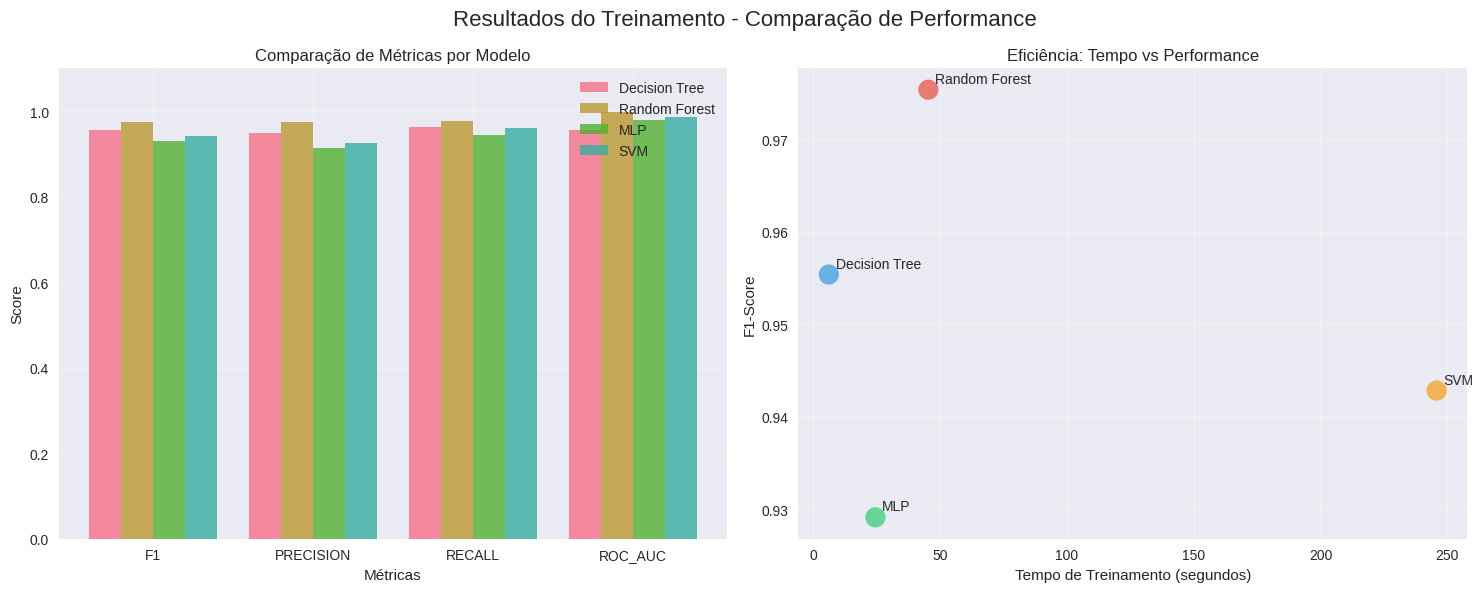

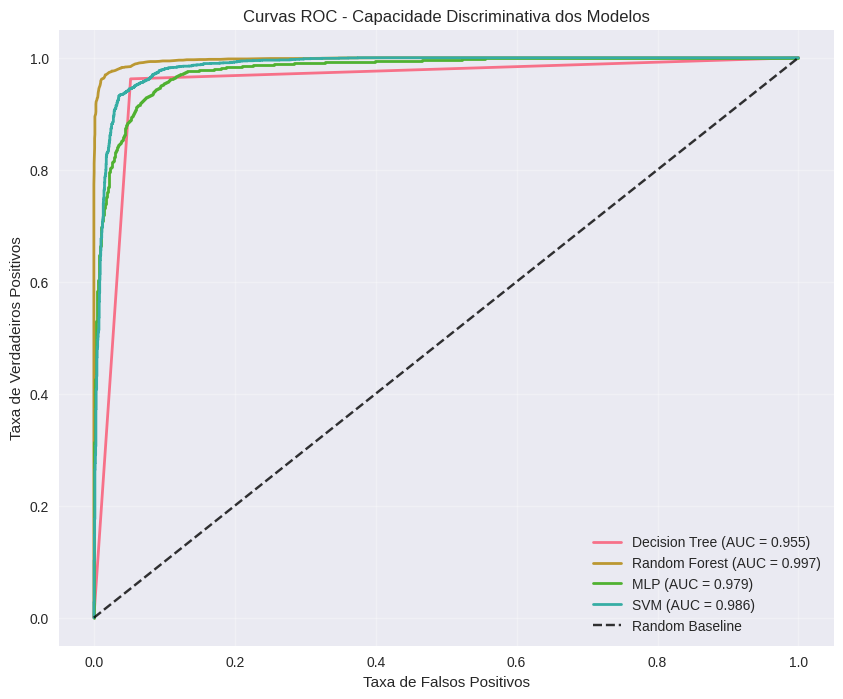

In [ ]:
# ================================================================
# AVALIAÇÃO NO CONJUNTO DE TESTE
# ================================================================
print("\n📊 AVALIAÇÃO NO CONJUNTO DE TESTE")
print("-"*50)

test_results = {}

for model_name, model in best_models.items():
    print(f"\n🔍 Avaliando {model_name} no conjunto de teste...")

    # Predições
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Métricas de teste
    test_metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_proba),
        'kappa': cohen_kappa_score(y_test, y_pred)
    }

    test_results[model_name] = {
        'metrics': test_metrics,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

    # Imprimir métricas
    print(f"✓ Accuracy: {test_metrics['accuracy']:.4f}")
    print(f"✓ Precision: {test_metrics['precision']:.4f}")
    print(f"✓ Recall: {test_metrics['recall']:.4f}")
    print(f"✓ F1-Score: {test_metrics['f1']:.4f}")
    print(f"✓ ROC-AUC: {test_metrics['roc_auc']:.4f}")
    print(f"✓ Kappa: {test_metrics['kappa']:.4f}")

# ================================================================
# COMPARAÇÃO DE RESULTADOS
# ================================================================
print("\n📈 COMPARAÇÃO DE RESULTADOS - VALIDAÇÃO CRUZADA")
print("-"*50)

# Criar DataFrame com resultados de CV
cv_comparison = pd.DataFrame()
for model_name, result in results.items():
    row = {}
    for metric in scoring_metrics:
        row[f'{metric}_mean'] = result['cv_results'][metric]['mean']
        row[f'{metric}_std'] = result['cv_results'][metric]['std']
    row['training_time'] = result['training_time']
    cv_comparison = pd.concat([cv_comparison, pd.DataFrame([row], index=[model_name])])

print(cv_comparison.round(4))

print("\n📈 COMPARAÇÃO DE RESULTADOS - CONJUNTO DE TESTE")
print("-"*50)

# Criar DataFrame com resultados de teste
test_comparison = pd.DataFrame()
for model_name, result in test_results.items():
    row = result['metrics']
    test_comparison = pd.concat([test_comparison, pd.DataFrame([row], index=[model_name])])

print(test_comparison.round(4))

# ================================================================
# VISUALIZAÇÕES FOCADAS NO TREINAMENTO
# ================================================================
print("\n📊 GERANDO VISUALIZAÇÕES DO TREINAMENTO")
print("-"*50)

# 1. Comparação de métricas principais (FOCO: Performance geral)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Resultados do Treinamento - Comparação de Performance', fontsize=16)

# Gráfico 1: Métricas principais - CORRIGIDO
metrics_to_plot = ['f1', 'precision', 'recall', 'roc_auc']

x_pos = np.arange(len(metrics_to_plot))
width = 0.2

for i, model_name in enumerate(models.keys()):
    values = [test_results[model_name]['metrics'][metric] for metric in metrics_to_plot]
    axes[0].bar(x_pos + i*width, values, width,
               label=model_name, alpha=0.8)

axes[0].set_xlabel('Métricas')
axes[0].set_ylabel('Score')
axes[0].set_title('Comparação de Métricas por Modelo')
axes[0].set_xticks(x_pos + width * 1.5)
axes[0].set_xticklabels([m.upper() for m in metrics_to_plot])
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1.1)

# Gráfico 2: Tempo de treinamento vs Performance
f1_scores = [test_results[model]['metrics']['f1'] for model in models.keys()]
times = [training_times[model] for model in models.keys()]

scatter = axes[1].scatter(times, f1_scores, s=200, alpha=0.7,
                         c=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])

for i, model in enumerate(models.keys()):
    axes[1].annotate(model, (times[i], f1_scores[i]),
                    xytext=(5, 5), textcoords='offset points', fontsize=10)

axes[1].set_xlabel('Tempo de Treinamento (segundos)')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('Eficiência: Tempo vs Performance')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Curvas ROC (FOCO: Capacidade discriminativa)
plt.figure(figsize=(10, 8))
for model_name, result in test_results.items():
    fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
    auc_score = result['metrics']['roc_auc']
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline', alpha=0.8)
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curvas ROC - Capacidade Discriminativa dos Modelos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# ================================================================
# RANKING FINAL DOS MODELOS
# ================================================================
print("\n🏆 RANKING FINAL DOS MODELOS")
print("-"*50)

# Calcular score composto (média ponderada das métricas principais)
weights = {'f1': 0.4, 'precision': 0.2, 'recall': 0.3, 'roc_auc': 0.1}

final_scores = {}
for model_name, result in test_results.items():
    score = sum(weights[metric] * result['metrics'][metric]
                for metric in weights.keys())
    final_scores[model_name] = score

# Ordenar por score
ranking = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)

print("Ranking baseado em score composto (F1: 40%, Recall: 30%, Precision: 20%, AUC: 10%):")
for i, (model_name, score) in enumerate(ranking, 1):
    print(f"{i}º lugar: {model_name} - Score: {score:.4f}")

# Melhor modelo
best_model_name = ranking[0][0]
best_model = best_models[best_model_name]

print(f"\n🥇 MELHOR MODELO: {best_model_name}")
print(f"Score Final: {final_scores[best_model_name]:.4f}")
print(f"Hiperparâmetros otimizados: {results[best_model_name]['best_params']}")

# ================================================================
# RELATÓRIO FINAL OTIMIZADO
# ================================================================
print("\n📋 RELATÓRIO FINAL DO TREINAMENTO OTIMIZADO")
print("-"*50)

print(f"\n🚀 OTIMIZAÇÕES APLICADAS:")
print(f"✓ Grid Search reduzido: ~{total_combinations} modelos (vs ~4.500 original)")
print(f"✓ CV reduzido: 3-fold (vs 5-fold)")
print(f"✓ MLP com early stopping: parada automática quando não melhora")
print(f"✓ Random Forest paralelizado: uso de todos os cores CPU")
print(f"✓ Parâmetros otimizados: foco em combinações mais eficazes")

total_time = sum(training_times.values())
print(f"\n⏱️ TEMPO TOTAL DE TREINAMENTO: {total_time:.1f} segundos ({total_time/60:.1f} minutos)")

print(f"\n🎯 RESULTADOS:")
print(f"✓ Melhor modelo: {best_model_name}")
for metric, value in test_results[best_model_name]['metrics'].items():
    print(f"✓ {metric.capitalize()}: {value:.4f}")


print("\n" + "="*70)
print("TREINAMENTO OTIMIZADO CONCLUÍDO COM SUCESSO!")
print("="*70)


🏆 RANKING FINAL DOS MODELOS
--------------------------------------------------
Ranking baseado em score composto (F1: 40%, Recall: 30%, Precision: 20%, AUC: 10%):
1º lugar: Random Forest - Score: 0.9777
2º lugar: Decision Tree - Score: 0.9561
3º lugar: SVM - Score: 0.9490
4º lugar: MLP - Score: 0.9357

🥇 MELHOR MODELO: Random Forest
Score Final: 0.9777
Hiperparâmetros otimizados: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

📋 RELATÓRIO FINAL DO TREINAMENTO OTIMIZADO
--------------------------------------------------

🚀 OTIMIZAÇÕES APLICADAS:
✓ Grid Search reduzido: ~132 modelos (vs ~4.500 original)
✓ CV reduzido: 3-fold (vs 5-fold)
✓ MLP com early stopping: parada automática quando não melhora
✓ Random Forest paralelizado: uso de todos os cores CPU
✓ Parâmetros otimizados: foco em combinações mais eficazes

⏱️ TEMPO TOTAL DE TREINAMENTO: 321.8 segundos (5.4 minutos)

🎯 RESULTADOS:
✓ Melhor modelo: Random Forest
✓ Accu

AVALIAÇÃO FINAL - COMPARAÇÃO DE MODELOS
✅ Modelos: ['Decision Tree', 'Random Forest', 'MLP', 'SVM']
✅ Dados: Treino (12980, 6), Teste (5564, 6)

🔄 Validação Cruzada...
  📊 Decision Tree
     accuracy: 0.9447
     precision: 0.9352
     f1: 0.9453
     kappa: 0.8894
  📊 Random Forest
     accuracy: 0.9677
     precision: 0.9590
     f1: 0.9680
     kappa: 0.9354
  📊 MLP
     accuracy: 0.9202
     precision: 0.9075
     f1: 0.9214
     kappa: 0.8404
  📊 SVM
     accuracy: 0.9421
     precision: 0.9240
     f1: 0.9433
     kappa: 0.8841

🎯 Avaliação no Teste...

📊 Gerando Boxplots...


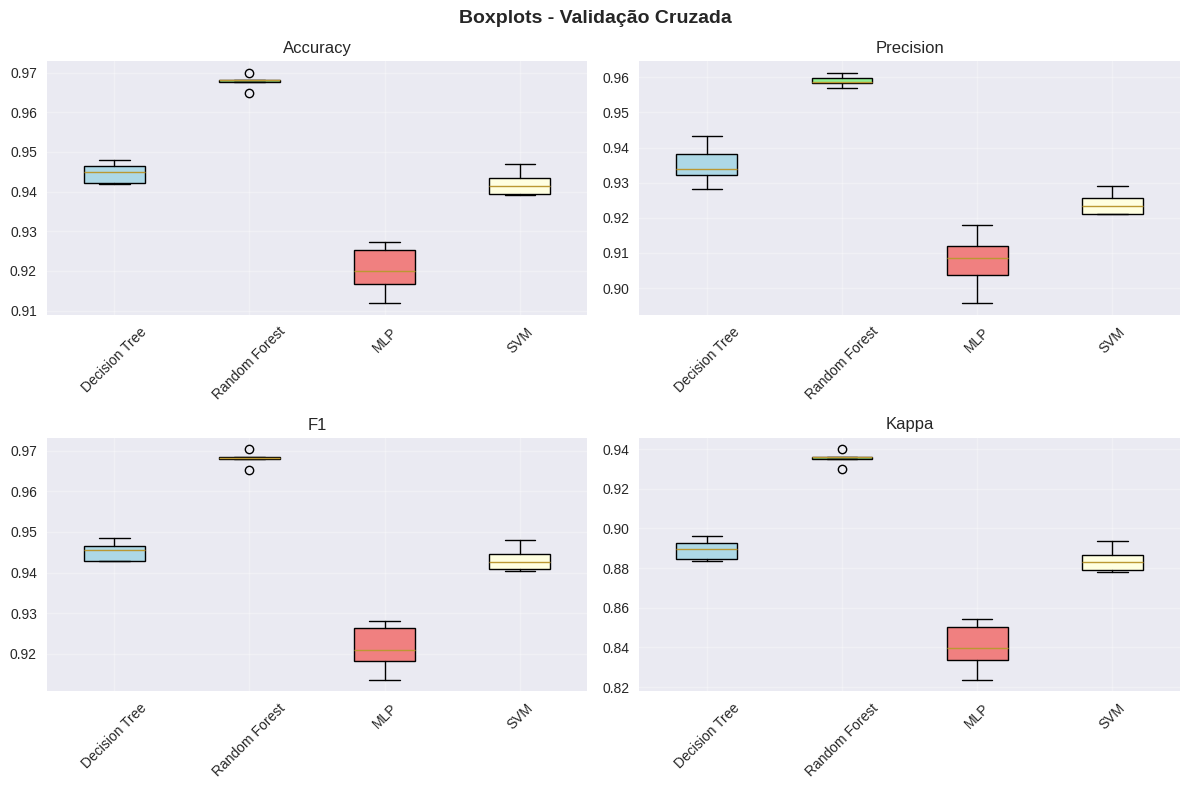

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (confusion_matrix, cohen_kappa_score, accuracy_score,
                           precision_score, f1_score, make_scorer)
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("AVALIAÇÃO FINAL - COMPARAÇÃO DE MODELOS")
print("="*60)

# ================================================================
# VERIFICAÇÃO E CONFIGURAÇÃO
# ================================================================
try:
    print(f"✅ Modelos: {list(best_models.keys())}")
    print(f"✅ Dados: Treino {X_train_scaled.shape}, Teste {X_test_scaled.shape}")
except NameError:
    print("❌ Execute primeiro: Pipeline + Treinamento ML")
    exit()

# Configuração
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metrics = ['accuracy', 'precision', 'f1']

# ================================================================
# VALIDAÇÃO CRUZADA
# ================================================================
print("\n🔄 Validação Cruzada...")
cv_results = {}

for model_name, model in best_models.items():
    print(f"  📊 {model_name}")

    # Métricas principais
    scores = {}
    for metric in metrics:
        scores[metric] = cross_val_score(model, X_train_scaled, y_train,
                                       cv=cv_strategy, scoring=metric)

    # Kappa
    kappa_scorer = make_scorer(cohen_kappa_score)
    scores['kappa'] = cross_val_score(model, X_train_scaled, y_train,
                                    cv=cv_strategy, scoring=kappa_scorer)

    cv_results[model_name] = scores

    # Exibir médias
    for metric in ['accuracy', 'precision', 'f1', 'kappa']:
        mean_score = scores[metric].mean()
        print(f"     {metric}: {mean_score:.4f}")

# ================================================================
# TESTE
# ================================================================
print("\n🎯 Avaliação no Teste...")
test_results = {}

for model_name, model in best_models.items():
    y_pred = model.predict(X_test_scaled)

    test_results[model_name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'kappa': cohen_kappa_score(y_test, y_pred),
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }

# ================================================================
# BOXPLOTS
# ================================================================
print("\n📊 Gerando Boxplots...")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Boxplots - Validação Cruzada', fontsize=14, fontweight='bold')

metrics_plot = ['accuracy', 'precision', 'f1', 'kappa']
positions = [(0,0), (0,1), (1,0), (1,1)]

for i, metric in enumerate(metrics_plot):
    ax = axes[positions[i]]

    # Dados para boxplot
    data = [cv_results[model][metric] for model in best_models.keys()]
    labels = list(best_models.keys())

    # Boxplot
    bp = ax.boxplot(data, labels=labels, patch_artist=True)

    # Colorir
    colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow']
    for patch, color in zip(bp['boxes'], colors[:len(labels)]):
        patch.set_facecolor(color)

    ax.set_title(metric.capitalize())
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


🔢 Matrizes de Confusão...


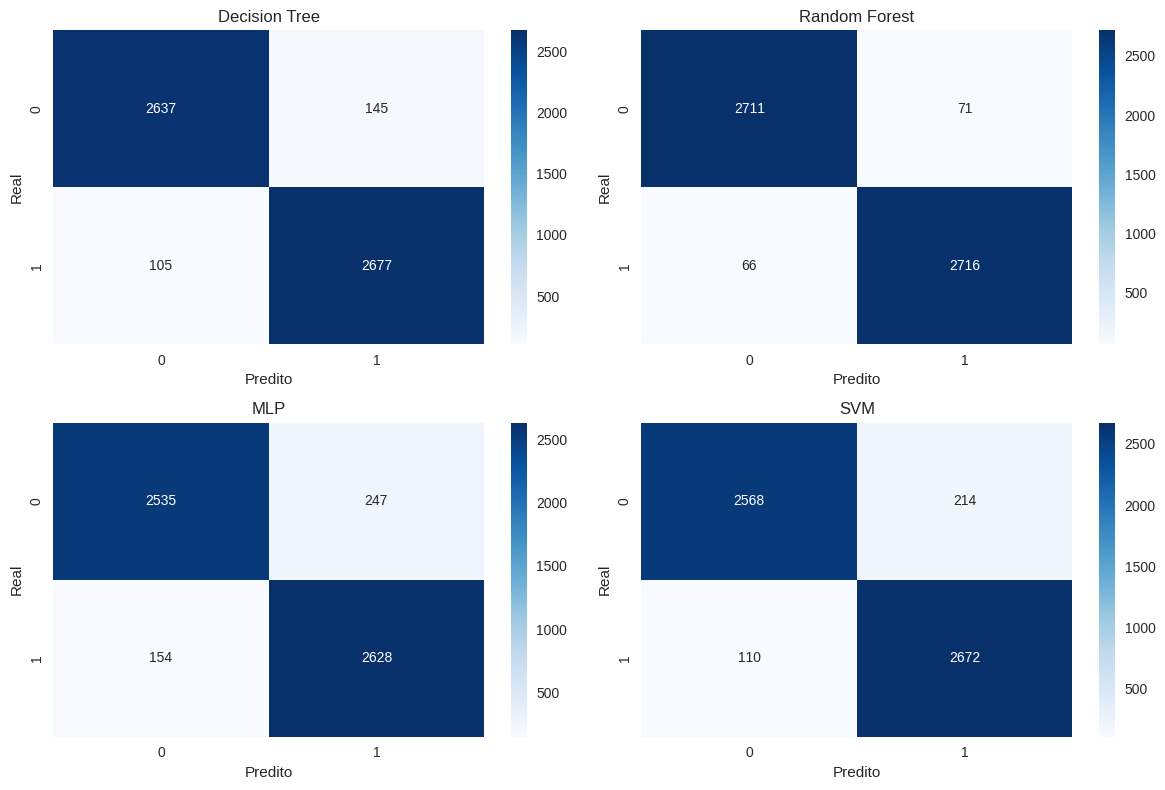


🏆 Ranking Final
----------------------------------------
1º Random Forest: Score=0.9715
   Acc=0.975 | Prec=0.975 | F1=0.975 | Kappa=0.951
2º Decision Tree: Score=0.9468
   Acc=0.955 | Prec=0.949 | F1=0.955 | Kappa=0.910
3º SVM: Score=0.9295
   Acc=0.942 | Prec=0.926 | F1=0.943 | Kappa=0.884
4º MLP: Score=0.9141
   Acc=0.928 | Prec=0.914 | F1=0.929 | Kappa=0.856

📋 Resumo Final
--------------------------------------------------
       Modelo Accuracy Precision F1-Score  Kappa
Decision Tree   0.9551    0.9486   0.9554 0.9101
Random Forest   0.9754    0.9745   0.9754 0.9508
          MLP   0.9279    0.9141   0.9291 0.8559
          SVM   0.9418    0.9258   0.9428 0.8835

🥇 MELHOR MODELO: Random Forest
🎯 Score Composto: 0.9715
✅ Qualidade: EXCELENTE

AVALIAÇÃO CONCLUÍDA!


In [ ]:
# ================================================================
# MATRIZES DE CONFUSÃO
# ================================================================
print("\n🔢 Matrizes de Confusão...")

n_models = len(best_models)
cols = min(n_models, 2)
rows = (n_models + 1) // 2

fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
if n_models == 1:
    axes = [axes]
elif rows == 1:
    axes = [axes] if n_models == 1 else axes
else:
    axes = axes.flatten()

for i, (model_name, _) in enumerate(best_models.items()):
    ax = axes[i] if n_models > 1 else axes[0]
    cm = test_results[model_name]['confusion_matrix']

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(model_name)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

# ================================================================
# RANKING
# ================================================================
print("\n🏆 Ranking Final")
print("-"*40)

# Score composto
weights = {'f1': 0.4, 'precision': 0.25, 'accuracy': 0.2, 'kappa': 0.15}

ranking = []
for model_name in best_models.keys():
    metrics_vals = test_results[model_name]
    score = sum(weights[m] * metrics_vals[m] for m in weights.keys())

    ranking.append({
        'modelo': model_name,
        'score': score,
        'accuracy': metrics_vals['accuracy'],
        'precision': metrics_vals['precision'],
        'f1': metrics_vals['f1'],
        'kappa': metrics_vals['kappa']
    })

# Ordenar
ranking.sort(key=lambda x: x['score'], reverse=True)

# Exibir
for i, r in enumerate(ranking, 1):
    print(f"{i}º {r['modelo']}: Score={r['score']:.4f}")
    print(f"   Acc={r['accuracy']:.3f} | Prec={r['precision']:.3f} | F1={r['f1']:.3f} | Kappa={r['kappa']:.3f}")

# ================================================================
# TABELA RESUMO
# ================================================================
print(f"\n📋 Resumo Final")
print("-"*50)

# Criar DataFrame
df_results = pd.DataFrame([
    {
        'Modelo': model_name,
        'Accuracy': f"{test_results[model_name]['accuracy']:.4f}",
        'Precision': f"{test_results[model_name]['precision']:.4f}",
        'F1-Score': f"{test_results[model_name]['f1']:.4f}",
        'Kappa': f"{test_results[model_name]['kappa']:.4f}"
    }
    for model_name in best_models.keys()
])

print(df_results.to_string(index=False))

# Melhor modelo
best_model = ranking[0]
print(f"\n🥇 MELHOR MODELO: {best_model['modelo']}")
print(f"🎯 Score Composto: {best_model['score']:.4f}")

if best_model['score'] > 0.85:
    print("✅ Qualidade: EXCELENTE")
elif best_model['score'] > 0.75:
    print("✅ Qualidade: MUITO BOA")
else:
    print("⚠️ Qualidade: BOA")

print("\n" + "="*60)
print("AVALIAÇÃO CONCLUÍDA!")
print("="*60)